# Wasted 8 years, worked hard for 1: can I still reach my goal?
### A visual, step-by-step walk through the dynamical model

*After wasting 8 years of life, if enough effort is given in 1 year, can someone reach the target, or a reachable target?*
The model includes **frontier drift**, a **re-entry penalty**, a **guilt feedback loop** and a **capacity constraint**.

| # | Section | Visual |
|---|---|---|
| 1 | State vector and the causal structure | causal loop network, one panel per feedback loop |
| 2 | The wasted years: $R_0$, $A_0$, $d_0$ | line chart + **3D surface** of the starting gap |
| 3 | The race ratio $\Pi$ and critical history $h_c$ | **3D surface** with the $\Pi=1$ plane |
| 4 | The effort year as a 2-D system $(c, G)$ | phase portrait, nullclines, equilibria, Jacobian |
| 5 | The feedback, animated | **particle-flow animation** |
| 6 | How wasted years erase the good future | bifurcation diagram + **3D bifurcation cloud** |
| 7 | Same effort, different guilt | **animated 3D trajectories** |
| 8 | The race: output vs. frontier | **animated race** |
| 9 | Something effort cannot touch | controllability rank, feasibility ratio $\rho(T)$ |
| 10 | Play with it | interactive sliders |

> All charts are interactive: drag to rotate the 3D plots and press ▶ on the animations. Parameter values are illustrative, chosen so the default settings reproduce the conclusions in the notes.

## 0 · Setup and parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import networkx as nx
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import HTML, display

pio.renderers.default = "plotly_mimetype+notebook_connected"   # renders in VS Code and Jupyter

BLUE, ORANGE, AQUA, RED, VIOLET, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#4a3aa7", "#8a8984", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#ecebe7", "axes.edgecolor": "#c9c8c2",
                     "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
                     "axes.titleweight": "bold", "axes.titlelocation": "left", "legend.frameon": False})
PLOTLY_LAYOUT = dict(template="plotly_white", font=dict(family="Helvetica, Arial", size=12, color=INK),
                     margin=dict(l=40, r=20, t=50, b=40))

In [2]:
P = dict(
    h=8.0,      # years of history before the effort year (the "wasted" years)
    a=4.0,      # max output rate in the effort year: a = γ π φ0 H (1 − c0) n0
    zeta=1.0,   # ζ   field advancement rate
    gR=0.10,    # g_R how fast the frontier compounds
    dA=0.15,    # δ_A rate at which old output decays / loses relevance
    bphi=0.5,   # βφ̄  output rate during the wasted years
    mu=0.4,     # μ   how strongly guilt removes usable days, n(G) = n0 e^{−μG}
    n0=0.8,     # n0  baseline fraction of usable days
    theta=0.5,  # θ   re-entry penalty strength, κ(c) = 1 − θ E(d)
    eh=3.0,     # e_h half-saturation of the deficit penalty, E(d) = d/(d + e_h)
    gw=0.3,     # g_w guilt from lost / wasted days
    ge=0.8,     # g_e guilt from falling behind
    gK=0.5,     # g_K natural decay of guilt
    w=1.0,      # width of the self-esteem curve Ê(c) (rises with c)
)
P

{'h': 8.0,
 'a': 4.0,
 'zeta': 1.0,
 'gR': 0.1,
 'dA': 0.15,
 'bphi': 0.5,
 'mu': 0.4,
 'n0': 0.8,
 'theta': 0.5,
 'eh': 3.0,
 'gw': 0.3,
 'ge': 0.8,
 'gK': 0.5,
 'w': 1.0}

---
## 1 · The state vector and the causal structure

$$x(t)=\begin{pmatrix}A(t)\\R(t)\\S(t)\\G(t)\end{pmatrix}\qquad
\begin{aligned}
A &= \text{absolute legible output} & R &= \text{external frontier}\\
S &= \text{structural support} & G &= \text{guilt / hopelessness} \ (\ge 0)
\end{aligned}$$

Derived quantity: $c(t)=A(t)-R(t)$ (**$c<0$ means below parity**).

**Dynamics** (from the notes):
$$\dot A=\gamma\pi\,\phi(S)\,u_A-\delta_A A,\qquad \dot R=\zeta+g_R R,\qquad \dot S=\rho_S\eta u_S+\rho_1(1-\pi)u_A-\delta_S S$$
$$\dot G=g_w\left(1-n_0e^{-\mu G}\right)+g_e\left(1-\hat E(c)\right)-g_K G$$

**Capacity constraint:** $u_A+u_S\le L(G):=H(1-c_0)\,n_0e^{-\mu G}$. Guilt shrinks the total hours available.

We turn each term into a signed arrow and let the code find every feedback loop and its polarity (the product of the signs around it).

In [3]:
NODES = {"ζ": "field advance", "R": "frontier", "A": "output", "S": "structure", "c": "gap A−R",
         "κ": "re-entry", "u": "effort hours", "G": "guilt", "n": "usable days", "L": "capacity"}
EDGES = [  # (from, to, sign, equation term)
    ("ζ", "R", +1, "Ṙ = ζ + …"), ("R", "R", +1, "g_R R"), ("R", "c", -1, "c = A − R"),
    ("A", "c", +1, "c = A − R"), ("A", "A", -1, "−δ_A A"),
    ("c", "κ", +1, "κ = 1 − θE(d)"), ("κ", "A", +1, "a κ(c) …"),
    ("c", "G", -1, "g_e(1 − Ê(c))"), ("G", "G", -1, "−g_K G"),
    ("G", "n", -1, "n = n0 e^{−μG}"), ("n", "L", +1, "L = H(1−c0) n"),
    ("L", "u", +1, "u_A + u_S ≤ L"), ("u", "A", +1, "γπφ u_A"),
    ("u", "S", +1, "ρ u_S"), ("S", "A", +1, "φ(S) = S/(S+S½)"),
]
Gr = nx.DiGraph()
for f, t, s, term in EDGES:
    Gr.add_edge(f, t, sign=s, term=term)

loops = []
for cyc in nx.simple_cycles(Gr):
    sign = np.prod([Gr[cyc[i]][cyc[(i + 1) % len(cyc)]]["sign"] for i in range(len(cyc))])
    loops.append((cyc, "reinforcing (+)" if sign > 0 else "balancing (−)"))
for cyc, kind in sorted(loops, key=lambda x: -len(x[0])):
    print(f"{kind:17s}  " + " → ".join(cyc + [cyc[0]]))

reinforcing (+)    c → G → n → L → u → S → A → c
reinforcing (+)    c → G → n → L → u → A → c
reinforcing (+)    c → κ → A → c
reinforcing (+)    R → R
balancing (−)      A → A
balancing (−)      G → G


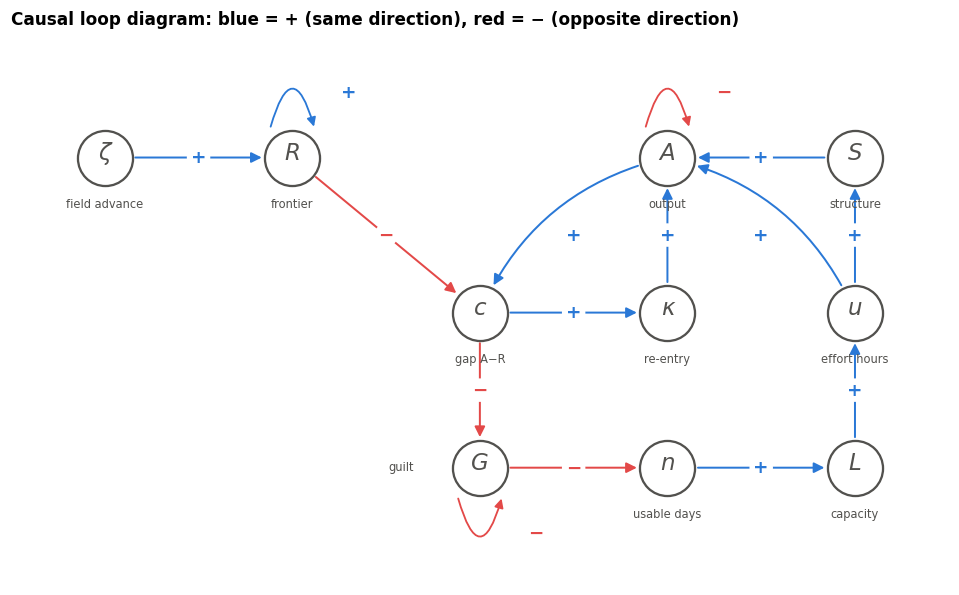

In [4]:
POS = {"ζ": (0, 2), "R": (1, 2), "A": (3, 2), "S": (4, 2),
       "c": (2, 1), "κ": (3, 1), "u": (4, 1),
       "G": (2, 0), "n": (3, 0), "L": (4, 0)}
LOOP_NAMES = {
    ("R",): "R1 · Frontier drift", ("A",): "B1 · Output decays", ("G",): "B2 · Guilt fades",
}
def loop_name(cyc):
    s = set(cyc)
    if len(cyc) == 1: return LOOP_NAMES[tuple(cyc)]
    if "G" in s and "S" in s: return "R4 · Guilt spiral via structure"
    if "G" in s and "n" in s: return "R2 · Guilt spiral"
    if "κ" in s: return "R3 · Re-entry penalty"
    return " → ".join(cyc)

def draw_cld(ax, highlight=None, title=""):
    hl_edges = set()
    if highlight:
        hl_edges = {(highlight[i], highlight[(i + 1) % len(highlight)]) for i in range(len(highlight))}
    for f, t, d in Gr.edges(data=True):
        on = (f, t) in hl_edges
        col = (BLUE if d["sign"] > 0 else RED) if (on or not highlight) else "#d9d8d3"
        if f == t:   # self loop: above the node, except guilt (below, clear of the c → G arrow)
            x, y = POS[f]; k = -1 if f == "G" else 1
            ax.add_patch(plt.matplotlib.patches.FancyArrowPatch((x - 0.12, y + k * 0.18), (x + 0.12, y + k * 0.18),
                         connectionstyle=f"arc3,rad={-1.8 * k}", arrowstyle="-|>", mutation_scale=12, color=col, lw=2 if on else 1.2))
            ax.text(x + 0.3, y + k * 0.42, "+" if d["sign"] > 0 else "−", ha="center", va="center", color=col, fontsize=12, weight="bold")
            continue
        rad = 0.25 if (f, t) in {("u", "A"), ("A", "c")} else 0.0
        arr = plt.matplotlib.patches.FancyArrowPatch(POS[f], POS[t], connectionstyle=f"arc3,rad={rad}", arrowstyle="-|>",
                                                     mutation_scale=14, color=col, lw=2.4 if on else 1.3, shrinkA=20, shrinkB=20)
        ax.add_patch(arr)
        mx, my = (np.array(POS[f]) + np.array(POS[t])) / 2
        ax.text(mx, my, "+" if d["sign"] > 0 else "−", ha="center", va="center", color=col, fontsize=12, weight="bold",
                bbox=dict(boxstyle="circle,pad=0.15", fc="white", ec="none"))
    on_nodes = set(highlight or NODES)
    for n, (x, y) in POS.items():
        ax.scatter(x, y, s=1300, color="white", edgecolor=INK if n in on_nodes else "#d9d8d3", linewidth=1.5, zorder=3)
        ax.text(x, y + 0.03, n, ha="center", va="center", fontsize=15, style="italic", zorder=4,
                color=INK if n in on_nodes else "#bdbcb6")
        gx, gy = (x - 0.42, y) if n == "G" else (x, y - 0.3)
        ax.text(gx, gy, NODES[n], ha="center", va="center", fontsize=7.5, color=INK if n in on_nodes else "#bdbcb6")
    ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.75, 2.8); ax.axis("off"); ax.set_title(title, fontsize=11)

fig, ax = plt.subplots(figsize=(11, 6.5))
draw_cld(ax, title="Causal loop diagram: blue = + (same direction), red = − (opposite direction)")
plt.show()

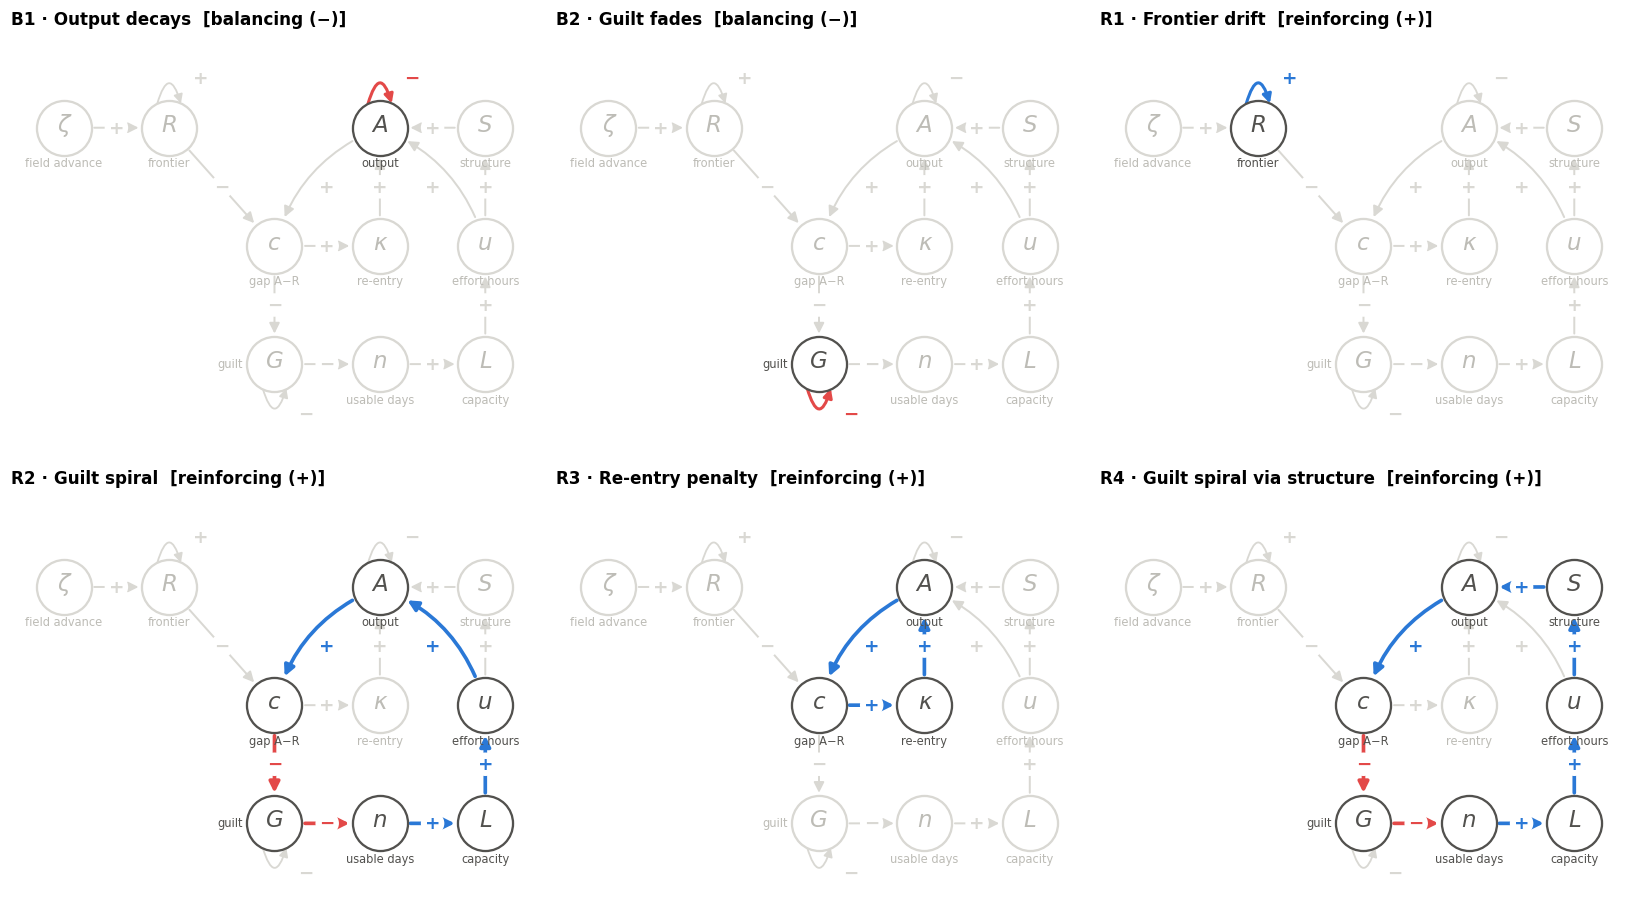

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for ax, (cyc, kind) in zip(axes.flat, sorted(loops, key=lambda x: loop_name(x[0]))):
    draw_cld(ax, highlight=cyc, title=f"{loop_name(cyc)}  [{kind}]")
plt.tight_layout(); plt.show()

**Reading the loops.** Four loops are **reinforcing**, so they push the gap wider:
- **R1 · Frontier drift:** the field compounds on itself, and nothing you control appears in it.
- **R2 · Guilt spiral:** behind → guilt ↑ → usable days ↓ → capacity ↓ → hours ↓ → output ↓ → further behind.
- **R3 · Re-entry penalty:** the further behind you are, the less each hour is worth.
- **R4 · Guilt spiral via structure:** guilt also starves the hours that build structure S, which lowers the capability multiplier φ(S).

Only two loops are **balancing** (old output decays; guilt fades naturally). The field advance ζ is an outside driver, not part of any loop.

---
## 2 · The wasted years: how big is the gap when effort begins?

$\dot R=\zeta+g_R R$ is a first-order non-homogeneous ODE with no control in it, so it can be solved on its own:
$$R_0=\frac{\zeta}{g_R}\left(e^{g_R h}-1\right)$$
During the wasted years, output builds slowly while old output decays. By the weighted mean-value theorem:
$$A_0=\frac{\beta\bar\phi}{\delta_A}\left(1-e^{-\delta_A h}\right)\le\frac{\beta\bar\phi}{\delta_A}\quad\text{(bounded)}$$
$$\boxed{d_0=R_0-A_0}\qquad d_0\to\infty\ \text{as}\ h\to\infty\iff\delta_A>0\ \text{or}\ g_R>0$$

R0 = 12.26   A0 = 2.33   d0 = 9.93   ζ_eff = 4.06


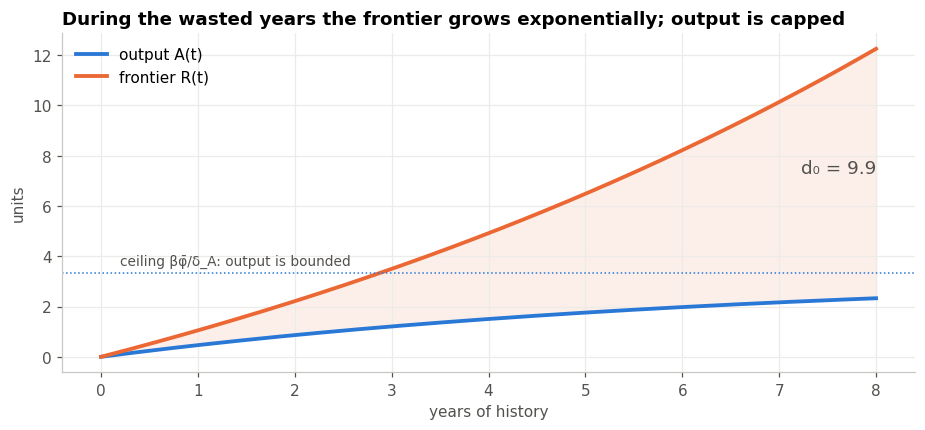

In [6]:
def pre_effort(p):
    R0 = p["zeta"] / p["gR"] * (np.exp(p["gR"] * p["h"]) - 1)
    A0 = p["bphi"] / p["dA"] * (1 - np.exp(-p["dA"] * p["h"]))
    zeff = p["zeta"] + (p["gR"] + p["dA"]) * R0          # effective drift (notes p.4-5)
    return dict(R0=R0, A0=A0, d0=R0 - A0, zeff=zeff)

D = pre_effort(P)
print(f"R0 = {D['R0']:.2f}   A0 = {D['A0']:.2f}   d0 = {D['d0']:.2f}   ζ_eff = {D['zeff']:.2f}")

t = np.linspace(0, P["h"], 200)
R_t = P["zeta"] / P["gR"] * (np.exp(P["gR"] * t) - 1)
A_t = P["bphi"] / P["dA"] * (1 - np.exp(-P["dA"] * t))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, A_t, color=BLUE, lw=2.5, label="output A(t)")
ax.plot(t, R_t, color=ORANGE, lw=2.5, label="frontier R(t)")
ax.fill_between(t, A_t, R_t, color=ORANGE, alpha=0.1)
ax.axhline(P["bphi"] / P["dA"], color=BLUE, ls=":", lw=1)
ax.text(0.2, P["bphi"] / P["dA"] + 0.3, "ceiling βφ̄/δ_A: output is bounded", color=INK, fontsize=9)
ax.annotate(f"d₀ = {D['d0']:.1f}", (P["h"], (D["R0"] + D["A0"]) / 2), ha="right", fontsize=12, color=INK)
ax.set_xlabel("years of history"); ax.set_ylabel("units"); ax.legend(loc="upper left")
ax.set_title("During the wasted years the frontier grows exponentially; output is capped")
plt.show()

In [7]:
# 3D: the starting gap d0 as a function of wasted years h and field speed g_R
hs = np.linspace(0, 15, 61); gRs = np.linspace(0.02, 0.2, 46)
Hh, GG = np.meshgrid(hs, gRs)
D0 = P["zeta"] / GG * (np.exp(GG * Hh) - 1) - P["bphi"] / P["dA"] * (1 - np.exp(-P["dA"] * Hh))
fig = go.Figure([
    go.Surface(x=hs, y=gRs, z=D0, colorscale="Oranges", colorbar=dict(title="d₀"),
               hovertemplate="h=%{x:.1f} yr<br>g_R=%{y:.3f}<br>d₀=%{z:.1f}<extra></extra>"),
    go.Scatter3d(x=[P["h"]], y=[P["gR"]], z=[D["d0"]], mode="markers+text", text=["you"],
                 marker=dict(size=7, color=BLUE, line=dict(color="white", width=2)), textposition="top center"),
])
fig.update_layout(**PLOTLY_LAYOUT, height=560, title="Starting gap d₀: grows exponentially in the wasted years",
                  scene=dict(xaxis_title="wasted years h", yaxis_title="field speed g_R", zaxis_title="gap d₀",
                             camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9))))
fig.show()

---
## 3 · The race ratio $\Pi$: can maximum effort even keep pace?

In the effort year, with $A=c+R$ and the frontier frozen at $R_0$:
$$\dot c=a\,\kappa(c)\,e^{-\mu G}-\delta_A c-\zeta_{\text{eff}},\qquad a:=\gamma\pi\phi_0H(1-c_0)n_0,\qquad \zeta_{\text{eff}}=\zeta\left[1+\left(1+\tfrac{\delta_A}{g_R}\right)\left(e^{g_Rh}-1\right)\right]$$

**Critical history length.** Define the race ratio $\Pi:=a/\zeta_{\text{eff}}$. If $\Pi<1$ then $\dot c<0$ *even with maximum effort, zero guilt and full capacity*.
$$\Pi(h)=\frac{\Pi_0}{1+\left(1+\delta_A/g_R\right)\left(e^{g_Rh}-1\right)},\quad \Pi_0=\frac{a}{\zeta}\qquad\Longrightarrow\qquad h_c=\frac1{g_R}\ln\!\left[1+\frac{(\Pi_0-1)\,g_R}{g_R+\delta_A}\right]$$

In [8]:
def race_ratio(h, Pi0, p=P):
    return Pi0 / (1 + (1 + p["dA"] / p["gR"]) * (np.exp(p["gR"] * h) - 1))
def h_crit(Pi0, p=P):
    return np.log(1 + (Pi0 - 1) * p["gR"] / (p["gR"] + p["dA"])) / p["gR"]

Pi0 = P["a"] / P["zeta"]
print(f"Π0 = {Pi0:.2f}   Π(h={P['h']:.0f}) = {race_ratio(P['h'], Pi0):.3f}   critical history h_c = {h_crit(Pi0):.2f} years")
print("→ past the critical history: the gap widens even at full effort" if P["h"] > h_crit(Pi0)
      else "→ still inside the critical history: catching up is possible at full effort")

Π0 = 4.00   Π(h=8) = 0.984   critical history h_c = 7.88 years
→ past the critical history: the gap widens even at full effort


In [9]:
hs = np.linspace(0, 15, 61); p0s = np.linspace(1, 10, 46)
Z = np.array([[race_ratio(h, p0) for h in hs] for p0 in p0s])
hc_line = np.array([h_crit(p0) for p0 in p0s])
fig = go.Figure([
    go.Surface(x=hs, y=p0s, z=Z, colorscale="Blues", showscale=False, opacity=0.95,
               contours=dict(z=dict(show=True, start=0, end=10, size=0.5, color="#8a8984")),
               hovertemplate="h=%{x:.1f}<br>Π0=%{y:.1f}<br>Π=%{z:.2f}<extra></extra>"),
    go.Surface(x=[0, 15], y=[1, 10], z=[[1, 1], [1, 1]], colorscale=[[0, ORANGE], [1, ORANGE]],
               showscale=False, opacity=0.35, hoverinfo="skip"),
    go.Scatter3d(x=np.minimum(hc_line, 15), y=p0s, z=np.ones_like(p0s) * 1.001, mode="lines",
                 line=dict(color="white", width=8), name="critical history h_c"),
    go.Scatter3d(x=[P["h"]], y=[Pi0], z=[race_ratio(P["h"], Pi0)], mode="markers+text", text=["you"],
                 marker=dict(size=7, color=ORANGE, line=dict(color="white", width=2)), textposition="top center", name="you"),
])
fig.update_layout(**PLOTLY_LAYOUT, height=600, showlegend=False,
                  title="Race ratio Π: below the orange plane (Π < 1) the gap widens even at full effort",
                  scene=dict(xaxis_title="wasted years h", yaxis_title="Π0 = a/ζ", zaxis_title="Π",
                             camera=dict(eye=dict(x=1.7, y=-1.5, z=0.9)), aspectratio=dict(x=1.2, y=1, z=0.7)))
fig.show()

---
## 4 · The effort year as a 2-D dynamical system $(c, G)$

$$\dot c=a\,\kappa(c)\,e^{-\mu G}-\delta_A c-\zeta_{\text{eff}}\qquad\dot G=g_w\left(1-n_0e^{-\mu G}\right)+g_e\left(1-\hat E(c)\right)-g_K G$$
with $\kappa(c)=1-\theta\,E(d)$, $E(d)=\dfrac{d}{d+e_h}$, $d=(-c)_+$ (the re-entry penalty), and $\hat E(c)$ a saturating self-esteem curve that rises with $c$.

**Linearising** around a fixed point $x^*$ with $\dot\delta=J\delta$:
$$J=\begin{pmatrix}\dfrac{aE\theta e_h}{(d+e_h)^2}-\delta_A & -a\mu\kappa E\\[4pt] -g_e\hat E'(c) & -P_g\end{pmatrix},\qquad E:=e^{-\mu G^*},\quad P_g:=g_K-g_w\mu n$$
- $J_{12}<0$: guilt costs days, and days cost output
- $J_{21}<0$: falling behind brings guilt
- $J_{22}<0$: guilt is self-limiting

**Saddle** $\iff \det J<0 \iff \underbrace{\dfrac{aE\theta e_h}{(d+e_h)^2}}_{\text{re-entry feedback}}+\underbrace{\dfrac{a\mu\kappa E g_e\hat E'}{P_g}}_{\text{guilt loop}}>\underbrace{\delta_A}_{\text{aging}}$

In [10]:
kappa = lambda c, p=P: 1 - p["theta"] * np.maximum(-c, 0) / (np.maximum(-c, 0) + p["eh"])
Ehat = lambda c, p=P: 1 / (1 + np.exp(-c / p["w"]))

def field(c, G, p=P, D=None):
    D = D or pre_effort(p)
    dc = p["a"] * kappa(c, p) * np.exp(-p["mu"] * G) - p["dA"] * c - D["zeff"]
    dG = p["gw"] * (1 - p["n0"] * np.exp(-p["mu"] * G)) + p["ge"] * (1 - Ehat(c, p)) - p["gK"] * G
    return dc, dG

def jacobian(c, G, p=P, D=None, e=1e-6):
    f = lambda x: np.array(field(x[0], x[1], p, D))
    return np.column_stack([(f([c + e, G]) - f([c - e, G])) / (2 * e), (f([c, G + e]) - f([c, G - e])) / (2 * e)])

def G_nullcline(c, p=P, iters=60):
    # Solve Ġ = 0 for G at each c. Ġ is decreasing in G whenever g_K > g_w μ n0, so bisection is safe.
    c = np.atleast_1d(c).astype(float)
    g = lambda G: p["gw"] * (1 - p["n0"] * np.exp(-p["mu"] * G)) + p["ge"] * (1 - Ehat(c, p)) - p["gK"] * G
    lo, hi = np.zeros_like(c), np.full_like(c, 50.0)
    for _ in range(iters):
        mid = (lo + hi) / 2; pos = g(mid) > 0
        lo, hi = np.where(pos, mid, lo), np.where(pos, hi, mid)
    return np.where(g(np.zeros_like(c)) < 0, 0.0, lo)

def fixed_points(p=P):
    # Equilibria = points on the Ġ=0 curve where ċ also vanishes: sign changes of ċ(c, G(c)), refined by Newton
    D = pre_effort(p)
    cs = np.linspace(-80, 40, 2401)
    r = field(cs, G_nullcline(cs, p), p, D)[0]
    out = []
    for i in np.where(np.sign(r[:-1]) != np.sign(r[1:]))[0]:
        s = fsolve(lambda x: field(x[0], x[1], p, D), [cs[i], G_nullcline(cs[i], p)[0]])
        J = jacobian(*s, p, D); ev = np.linalg.eigvals(J)
        typ = "saddle" if np.linalg.det(J) < 0 else ("stable" if np.trace(J) < 0 else "unstable")
        out.append(dict(x=s, c=s[0], G=s[1], J=J, eig=ev, type=typ))
    return out

def describe(fps):
    for q in fps:
        print(f"{q['type']:8s}  c* = {q['c']:7.2f}   G* = {q['G']:.2f}   eigenvalues = {np.round(q['eig'], 3)}")

print(f"h = {P['h']} years:"); describe(fixed_points(P))
print(f"\nh = 3 years (shorter history):"); describe(fixed_points({**P, "h": 3.0}))

h = 8.0 years:
stable    c* =  -20.28   G* = 1.98   eigenvalues = [-0.145 -0.457]

h = 3 years (shorter history):
stable    c* =   -3.49   G* = 1.93   eigenvalues = [-0.054 -0.486]
saddle    c* =   -2.00   G* = 1.77   eigenvalues = [ 0.07  -0.554]
stable    c* =   12.64   G* = 0.15   eigenvalues = [-0.15 -0.41]


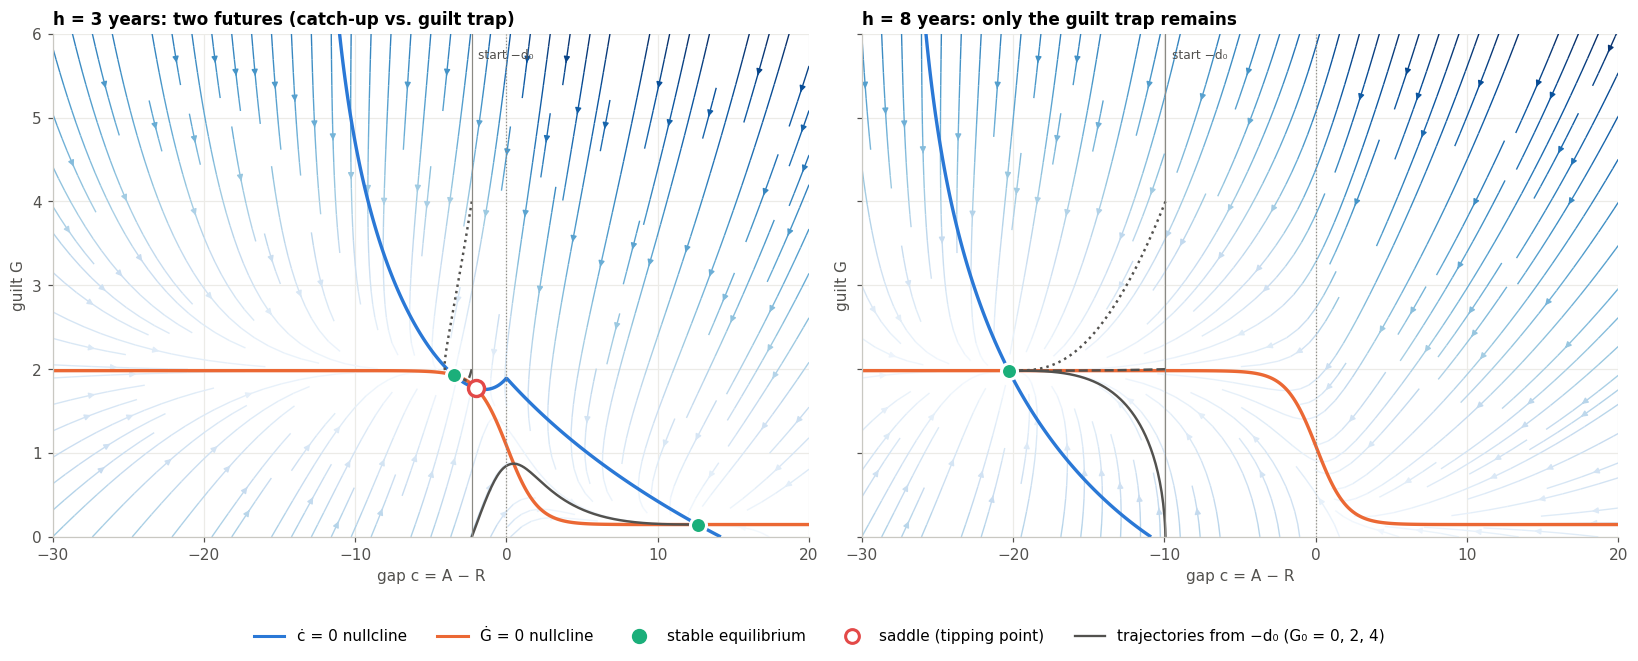

In [11]:
def phase_portrait(ax, p, title):
    D = pre_effort(p)
    c = np.linspace(-30, 20, 60); G = np.linspace(0, 6, 40)
    C, GG = np.meshgrid(c, G); U, V = field(C, GG, p, D)
    speed = np.hypot(U / 50, V / 6)
    ax.streamplot(C, GG, U, V, color=speed, cmap="Blues", density=1.3, linewidth=0.9, arrowsize=0.8)
    cc = np.linspace(-30, 20, 1000); CC, GGf = np.meshgrid(cc, np.linspace(0, 6, 600)); Uf, Vf = field(CC, GGf, p, D)
    ax.contour(CC, GGf, Uf, levels=[0], colors=[BLUE], linewidths=2.2)
    ax.contour(CC, GGf, Vf, levels=[0], colors=[ORANGE], linewidths=2.2)
    for q in fixed_points(p):
        if q["type"] == "stable": ax.scatter(q["c"], q["G"], s=110, color=AQUA, edgecolor="white", linewidth=2, zorder=5)
        else: ax.scatter(q["c"], q["G"], s=110, facecolor="white", edgecolor=RED, linewidth=2.2, zorder=5)
    for G0, ls in [(0, "-"), (2, "--"), (4, ":")]:
        sol = solve_ivp(lambda t, x: field(x[0], max(x[1], 0), p, D), [0, 40], [-D["d0"], G0], max_step=0.1)
        ax.plot(sol.y[0], sol.y[1], color=INK, lw=1.6, ls=ls)
    ax.axvline(-D["d0"], color=GRAY, lw=0.8); ax.text(-D["d0"] + 0.4, 5.7, "start −d₀", fontsize=8, color=INK)
    ax.axvline(0, color=GRAY, lw=0.8, ls=":")
    ax.set_xlim(-30, 20); ax.set_ylim(0, 6); ax.set_xlabel("gap c = A − R"); ax.set_ylabel("guilt G"); ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), sharey=True)
phase_portrait(axes[0], {**P, "h": 3.0}, "h = 3 years: two futures (catch-up vs. guilt trap)")
phase_portrait(axes[1], P, f"h = {P['h']:.0f} years: only the guilt trap remains")
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([], [], color=BLUE, lw=2, label="ċ = 0 nullcline"), Line2D([], [], color=ORANGE, lw=2, label="Ġ = 0 nullcline"),
                    Line2D([], [], marker="o", ls="", color=AQUA, ms=9, label="stable equilibrium"),
                    Line2D([], [], marker="o", ls="", mfc="white", mec=RED, ms=9, mew=2, label="saddle (tipping point)"),
                    Line2D([], [], color=INK, lw=1.5, label="trajectories from −d₀ (G₀ = 0, 2, 4)")],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

In [12]:
# Check the saddle condition from the notes term by term at each fixed point (h = 3 case)
p4 = {**P, "h": 3.0}
for q in fixed_points(p4):
    c, G = q["c"], q["G"]; d = max(-c, 0); E = np.exp(-p4["mu"] * G); n = p4["n0"] * E
    Pg = p4["gK"] - p4["gw"] * p4["mu"] * n
    Ehat_p = Ehat(c, p4) * (1 - Ehat(c, p4)) / p4["w"]
    reentry = p4["a"] * E * p4["theta"] * p4["eh"] / (d + p4["eh"]) ** 2 if c < 0 else 0.0
    guilt = p4["a"] * p4["mu"] * kappa(c, p4) * E * p4["ge"] * Ehat_p / Pg
    print(f"{q['type']:8s} c*={c:6.2f}: re-entry {reentry:.3f} + guilt loop {guilt:.3f} "
          f"{'>' if reentry + guilt > p4['dA'] else '<'} aging δ_A={p4['dA']}  → saddle? {reentry + guilt > p4['dA']}")

stable   c*= -3.49: re-entry 0.066 + guilt loop 0.027 < aging δ_A=0.15  → saddle? False
saddle   c*= -2.00: re-entry 0.118 + guilt loop 0.117 > aging δ_A=0.15  → saddle? True
stable   c*= 12.64: re-entry 0.000 + guilt loop 0.000 < aging δ_A=0.15  → saddle? False


---
## 5 · The feedback, animated: particle flow

Each dot is a possible version of you, carried along by the equations for $(\dot c,\dot G)$. Watch them drain into the stable equilibria. On the left (short history) the saddle splits the dots between two fates. On the right (8 wasted years) everything drains into the trap.

In [13]:
def particle_animation(p_left, p_right, n=600, frames=60, seed=1):
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True, dpi=72)
    systems = []
    for ax, p, ttl in [(axes[0], p_left, f"h = {p_left['h']:.0f} yr"), (axes[1], p_right, f"h = {p_right['h']:.0f} yr")]:
        D = pre_effort(p)
        cc = np.linspace(-30, 20, 500); CC, GGf = np.meshgrid(cc, np.linspace(0, 6, 300)); Uf, Vf = field(CC, GGf, p, D)
        ax.contour(CC, GGf, Uf, levels=[0], colors=[BLUE], linewidths=1.8)
        ax.contour(CC, GGf, Vf, levels=[0], colors=[ORANGE], linewidths=1.8)
        for q in fixed_points(p):
            ax.scatter(q["c"], q["G"], s=90, zorder=5, **(dict(color=AQUA, edgecolor="white", linewidth=2) if q["type"] == "stable"
                                                     else dict(facecolor="white", edgecolor=RED, linewidth=2)))
        pts = np.column_stack([rng.uniform(-30, 20, n), rng.uniform(0, 6, n)])
        sc = ax.scatter(pts[:, 0], pts[:, 1], s=5, color=BLUE, alpha=0.6)
        ax.set_xlim(-30, 20); ax.set_ylim(0, 6); ax.set_xlabel("gap c"); ax.set_title(ttl)
        systems.append((p, D, pts, sc))
    axes[0].set_ylabel("guilt G")
    plt.tight_layout()

    def step(_):
        for p, D, pts, sc in systems:
            for _ in range(6):
                u, v = field(pts[:, 0], pts[:, 1], p, D)
                pts[:, 0] += 0.05 * u; pts[:, 1] = np.maximum(pts[:, 1] + 0.05 * v, 0)
            sc.set_offsets(pts)
        return [s[3] for s in systems]
    anim = animation.FuncAnimation(fig, step, frames=frames, interval=60, blit=True)
    plt.close(fig)
    return anim

plt.rcParams["animation.embed_limit"] = 60
HTML(particle_animation({**P, "h": 3.0}, P).to_jshtml())

---
## 6 · How the wasted years erase the good future (bifurcation)

We track every equilibrium $c^*$ as the history length $h$ grows. There are three regimes:
- **short history:** only the catch-up equilibrium exists
- **middle window:** two futures, catch-up and guilt trap, split by a saddle (*bistable*)
- **long history:** the catch-up equilibrium collides with the saddle and both vanish, a *saddle-node bifurcation*. Only the trap is left.

Bistable window: 3.0 < h < 6.2 years


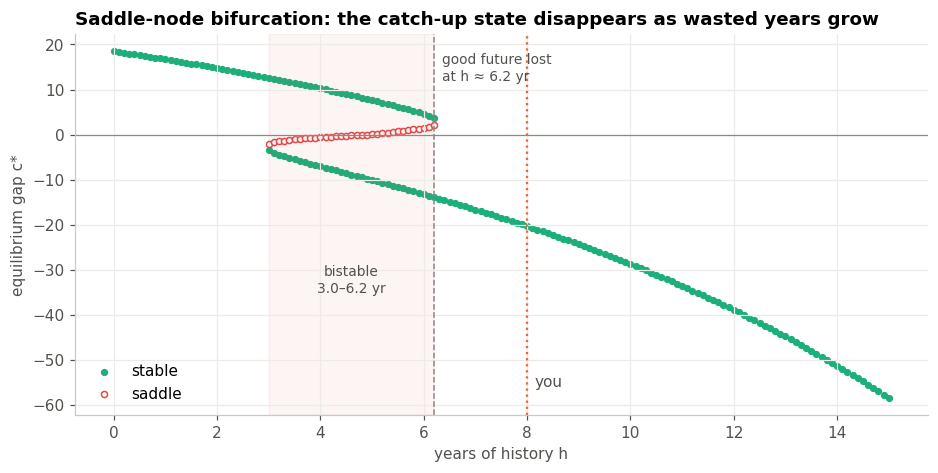

In [14]:
rows = []
for h in np.arange(0, 15.01, 0.1):
    for q in fixed_points({**P, "h": h}):
        rows.append((h, q["c"], q["G"], q["type"]))
rows = np.array(rows, dtype=object)
fig, ax = plt.subplots(figsize=(10, 4.5))
for typ, style in [("stable", dict(color=AQUA, s=14)), ("saddle", dict(facecolor="white", edgecolor=RED, s=16, linewidth=1))]:
    m = rows[:, 3] == typ
    ax.scatter(rows[m, 0].astype(float), rows[m, 1].astype(float), label=typ, **style)
sad_h = rows[rows[:, 3] == "saddle", 0].astype(float)
h_lo, h_bif = sad_h.min(), sad_h.max()
ax.axvspan(h_lo, h_bif, color=RED, alpha=0.06)
ax.text((h_lo + h_bif) / 2, -35, f"bistable\n{h_lo:.1f}–{h_bif:.1f} yr", ha="center", fontsize=9, color=INK)
ax.axvline(h_bif, color=GRAY, ls="--", lw=1); ax.text(h_bif + 0.15, 12, f"good future lost\nat h ≈ {h_bif:.1f} yr", fontsize=9, color=INK)
print(f"Bistable window: {h_lo:.1f} < h < {h_bif:.1f} years")
ax.axvline(P["h"], color=ORANGE, lw=1.5, ls=":"); ax.text(P["h"] + 0.15, ax.get_ylim()[0] * 0.9, "you", color=INK)
ax.axhline(0, color=GRAY, lw=0.8)
ax.set_xlabel("years of history h"); ax.set_ylabel("equilibrium gap c*"); ax.legend(loc="lower left")
ax.set_title("Saddle-node bifurcation: the catch-up state disappears as wasted years grow")
plt.show()

In [15]:
# 3D: equilibria over (h, μ): how guilt sensitivity moves the tipping point
pts = []
for h in np.arange(0, 12.01, 0.4):
    for mu in np.arange(0.1, 1.01, 0.05):
        for q in fixed_points({**P, "h": h, "mu": mu}):
            pts.append((h, mu, q["c"], q["type"]))
pts = np.array(pts, dtype=object)
fig = go.Figure()
for typ, col, sym in [("stable", AQUA, "circle"), ("saddle", RED, "circle-open")]:
    m = pts[:, 3] == typ
    fig.add_trace(go.Scatter3d(x=pts[m, 0], y=pts[m, 1], z=pts[m, 2], mode="markers", name=typ,
                               marker=dict(size=3, color=col, symbol=sym),
                               hovertemplate="h=%{x:.1f}<br>μ=%{y:.2f}<br>c*=%{z:.1f}<extra>" + typ + "</extra>"))
fig.update_layout(**PLOTLY_LAYOUT, height=600, title="Equilibrium landscape over wasted years h and guilt sensitivity μ",
                  scene=dict(xaxis_title="wasted years h", yaxis_title="guilt → lost days μ", zaxis_title="equilibrium gap c*",
                             camera=dict(eye=dict(x=1.8, y=-1.4, z=0.8))))
fig.show()

---
## 7 · Same effort, different starting guilt (animated 3D)

The trajectories start at the same gap $-d_0$ but carry different initial guilt $G_0$. Press ▶ to watch them unfold in (time, gap, guilt) space. The case shown is **h = 3 years**, where both futures exist. From the same starting gap, **G₀ ≤ 1 escapes to catch-up and G₀ ≥ 2 falls into the trap**. Guilt alone decides the outcome.

In [16]:
p_demo = {**P, "h": 3.0}; Dd = pre_effort(p_demo)
T = np.linspace(0, 30, 151); G0s = [0, 1, 2, 3, 4, 5]
sols = [solve_ivp(lambda t, x: field(x[0], max(x[1], 0), p_demo, Dd), [0, 30], [-Dd["d0"], g0], t_eval=T, max_step=0.1).y for g0 in G0s]
shades = ["#c7daf3", "#9bbfec", "#6ba1e2", "#3f86db", "#1f5fae", "#123a6b"]   # light → dark = low → high guilt

def traces(k):
    return [go.Scatter3d(x=T[:k], y=s[0, :k], z=s[1, :k], mode="lines", line=dict(color=col, width=6), name=f"G₀ = {g0}")
            for s, col, g0 in zip(sols, shades, G0s)]

fig = go.Figure(data=traces(2), frames=[go.Frame(data=traces(k), name=str(k)) for k in range(5, 152, 5)])
fig.update_layout(**PLOTLY_LAYOUT, height=620, title="Trajectories in (time, gap, guilt): darker = more initial guilt",
    scene=dict(xaxis=dict(title="years of effort", range=[0, 30]),
               yaxis=dict(title="gap c", range=[min(s[0].min() for s in sols) - 1, max(s[0].max() for s in sols) + 1]),
               zaxis=dict(title="guilt G", range=[0, 6]), camera=dict(eye=dict(x=1.6, y=1.6, z=0.8)),
               aspectratio=dict(x=1.4, y=1, z=0.7)),
    updatemenus=[dict(type="buttons", x=0, y=1.02, xanchor="left", buttons=[
        dict(label="▶ Play", method="animate", args=[None, dict(frame=dict(duration=40, redraw=True), fromcurrent=True)]),
        dict(label="❚❚ Pause", method="animate", args=[[None], dict(mode="immediate", frame=dict(duration=0))])])])
fig.show()

---
## 8 · The race: output vs. frontier (animated)

This is the full model with the frontier **not** frozen: $\dot A=a\,\kappa(c)e^{-\mu G}-\delta_A A$, $\dot R=\zeta+g_RR$, and the guilt equation. It runs through the wasted years and then 10 effort years, for two starting guilt levels.

In [17]:
def race(p, G0, T_eff=10):
    D = pre_effort(p)
    t_pre = np.linspace(0, p["h"], 40)
    pre = dict(t=t_pre - p["h"], R=p["zeta"] / p["gR"] * (np.exp(p["gR"] * t_pre) - 1),
               A=p["bphi"] / p["dA"] * (1 - np.exp(-p["dA"] * t_pre)))
    def f(t, x):
        A, R, G = x; c = A - R; G = max(G, 0)
        return [p["a"] * kappa(c, p) * np.exp(-p["mu"] * G) - p["dA"] * A, p["zeta"] + p["gR"] * R,
                p["gw"] * (1 - p["n0"] * np.exp(-p["mu"] * G)) + p["ge"] * (1 - Ehat(c, p)) - p["gK"] * G]
    te = np.linspace(0, T_eff, 81)
    s = solve_ivp(f, [0, T_eff], [D["A0"], D["R0"], G0], t_eval=te, max_step=0.05)
    return np.concatenate([pre["t"], te]), np.concatenate([pre["A"], s.y[0]]), np.concatenate([pre["R"], s.y[1]])

t_all, A_lo, R_all = race(P, 0.0)
_, A_hi, _ = race(P, 3.0)
N = len(t_all)
def tr(k):
    return [go.Scatter(x=t_all[:k], y=R_all[:k], name="frontier R", line=dict(color=ORANGE, width=3)),
            go.Scatter(x=t_all[:k], y=A_lo[:k], name="output A (G₀ = 0)", line=dict(color=BLUE, width=3)),
            go.Scatter(x=t_all[:k], y=A_hi[:k], name="output A (G₀ = 3)", line=dict(color=BLUE, width=2, dash="dot"))]
fig = go.Figure(data=tr(2), frames=[go.Frame(data=tr(k)) for k in range(3, N + 1, 3)])
fig.add_vrect(x0=-P["h"], x1=0, fillcolor=GRAY, opacity=0.1, line_width=0, annotation_text="wasted years", annotation_position="top left")
fig.add_annotation(x=5, y=R_all.max() * 0.98, text="effort years", showarrow=False)
fig.update_layout(**PLOTLY_LAYOUT, height=480, title=f"The race: h = {P['h']:.0f} wasted years, then maximum effort",
    xaxis=dict(title="years (0 = effort begins)", range=[-P["h"] - 0.3, 10.3]), yaxis=dict(title="units", range=[0, R_all.max() * 1.08]),
    legend=dict(orientation="h", y=1.1, x=0.35),
    updatemenus=[dict(type="buttons", x=0, y=1.14, xanchor="left", buttons=[
        dict(label="▶ Play", method="animate", args=[None, dict(frame=dict(duration=30, redraw=False), fromcurrent=True)])])])
fig.show()
print(f"After 10 effort years: frontier = {R_all[-1]:.1f}, output = {A_lo[-1]:.1f} (no guilt) vs {A_hi[-1]:.1f} (guilt 3)")

After 10 effort years: frontier = 50.5, output = 6.5 (no guilt) vs 5.4 (guilt 3)


---
## 9 · Something effort cannot touch

In matrix form:
$$\frac{d}{dt}\begin{pmatrix}A\\R\end{pmatrix}=\begin{pmatrix}-\delta_A&0\\0&g_R\end{pmatrix}\begin{pmatrix}A\\R\end{pmatrix}+\begin{pmatrix}b\\0\end{pmatrix}u_A+\begin{pmatrix}0\\\zeta\end{pmatrix},\qquad b:=\gamma\pi\phi_0$$
The controllability matrix $\mathcal C=[B\ \ AB]=\begin{pmatrix}b&-\delta_Ab\\0&0\end{pmatrix}$ has **rank 1 < 2**, so effort cannot move $R$.

**The best possible horizon.** The minimum-energy control gives the feasibility ratio against the budget $L$:
$$\rho(T)=\frac{2\Delta(T)}{bLT\,(1+e^{-\delta_AT})},\qquad \Delta(T)=A_{tgt}(T)-e^{-\delta_AT}A_0,\qquad \text{parity feasible}\iff\rho(T)\le1$$
For large $T$, $\rho(T)\sim\dfrac{2\zeta e^{g_Rh}}{g_R\,bL}\cdot\dfrac{e^{g_RT}}{T}$, which is minimised at $T^*=1/g_R$. That is an approximation for large $T$. The exact curve below is lowest earlier, around 5 years with these parameters, because $A_0$ and the $(1+e^{-\delta_AT})$ term still matter at short horizons.

Controllability matrix [B AB] =
 [[ 1.   -0.15]
 [ 0.    0.  ]] 
rank = 1 < 2 → the frontier R is uncontrollable


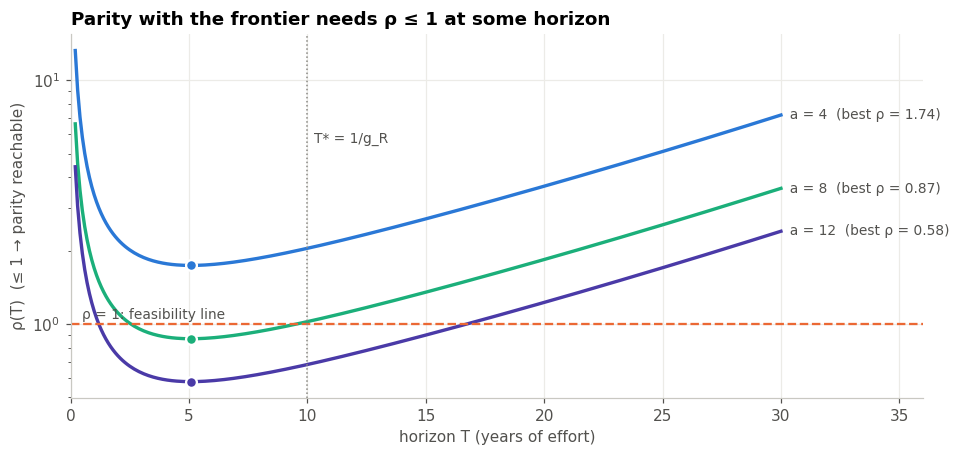

In [18]:
b = 1.0
Amat = np.array([[-P["dA"], 0], [0, P["gR"]]]); B = np.array([[b], [0]])
C = np.hstack([B, Amat @ B])
print("Controllability matrix [B AB] =\n", C, "\nrank =", np.linalg.matrix_rank(C), "< 2 → the frontier R is uncontrollable")

def rho(T, p=P):
    D = pre_effort(p)
    target = p["zeta"] / p["gR"] * (np.exp(p["gR"] * (p["h"] + T)) - 1)
    Delta = target - np.exp(-p["dA"] * T) * D["A0"]
    return 2 * Delta / (p["a"] * T * (1 + np.exp(-p["dA"] * T)))

T = np.linspace(0.2, 30, 300)
fig, ax = plt.subplots(figsize=(10, 4.3))
for a_val, col in [(P["a"], BLUE), (8.0, AQUA), (12.0, VIOLET)]:
    r = rho(T, {**P, "a": a_val}); i = r.argmin()
    ax.plot(T, r, color=col, lw=2.2)
    ax.scatter(T[i], r[i], color=col, s=50, edgecolor="white", linewidth=1.5, zorder=4)
    ax.text(T[-1], r[-1], f"  a = {a_val:g}  (best ρ = {r[i]:.2f})", color=INK, va="center", fontsize=9)
ax.axhline(1, color=ORANGE, ls="--", lw=1.5); ax.text(0.5, 1.05, "ρ = 1: feasibility line", color=INK, fontsize=9)
ax.axvline(1 / P["gR"], color=GRAY, ls=":", lw=1); ax.text(1 / P["gR"] + 0.3, ax.get_ylim()[1] * 0.4, "T* = 1/g_R", color=INK, fontsize=9)
ax.set_yscale("log"); ax.set_xlabel("horizon T (years of effort)"); ax.set_ylabel("ρ(T)  (≤ 1 → parity reachable)")
ax.set_title("Parity with the frontier needs ρ ≤ 1 at some horizon")
ax.set_xlim(0, 36); plt.show()

---
## 10 · Play with it

Move the sliders to redraw the phase portrait. This needs a running kernel: run the cell, then drag.

In [19]:
from ipywidgets import interact, FloatSlider
@interact(h=FloatSlider(value=8, min=0, max=15, step=0.5, description="wasted h"),
          a=FloatSlider(value=4, min=1, max=10, step=0.2, description="max rate a"),
          mu=FloatSlider(value=0.4, min=0, max=1, step=0.05, description="guilt μ"),
          ge=FloatSlider(value=0.8, min=0, max=2, step=0.05, description="behind→guilt"))
def explore(h, a, mu, ge):
    p = {**P, "h": h, "a": a, "mu": mu, "ge": ge}
    fig, ax = plt.subplots(figsize=(10, 5))
    Pi = race_ratio(h, a / p["zeta"], p)
    phase_portrait(ax, p, f"h={h}, a={a}, μ={mu}, g_e={ge}   |   d₀={pre_effort(p)['d0']:.1f}, Π={Pi:.2f}")
    plt.show()

interactive(children=(FloatSlider(value=8.0, description='wasted h', max=15.0, step=0.5), FloatSlider(value=4.…

---
## Summary

| Question | What the model says |
|---|---|
| How big is the gap after the wasted years? | $d_0$ grows **exponentially** in $h$ because the frontier compounds (§2). |
| Can maximum effort keep pace? | Only if $\Pi\ge1$. With these parameters $h_c\approx7.9$ years, so 8 wasted years is just past it (§3). |
| Is there more than one possible future? | For about 3–6 years of history there are two, catch-up and guilt trap, split by a saddle (§4, §6). |
| What do the wasted years do? | Past about 6.2 years they destroy the catch-up equilibrium through a saddle-node bifurcation (§6). |
| What can effort change? | Not the frontier: rank $[B\ AB]=1$ (§9). Effort changes your output and, through guilt, your capacity. |
| What is in your control? | **Guilt.** At h = 3, the same gap and the same effort lead to catch-up or to the trap depending only on starting guilt (§7). Your saddle condition from the notes matches the numerical check (§4). |

> *"It'll be impossible for the student to ever match the output to their input. But as long as they continue to go on without any guilt, they can work the best that day, and that's a great output toward that goal."*

**Caveats.** The parameter values are illustrative, not estimated from data. $S$ (structure) is folded into the constant $a$ in the effort-year analysis, and $\hat E(c)$ uses a logistic shape because the notes don't pin down its form.